In [1]:
import time
import numpy as np
import pandas as pd
from IPython.display import display

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.base import clone
from sklearn.datasets import make_moons
from sklearn.ensemble import (
    BaggingClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import (
    DecisionTreeClassifier,
    DecisionTreeRegressor,
    plot_tree
)

In [2]:
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

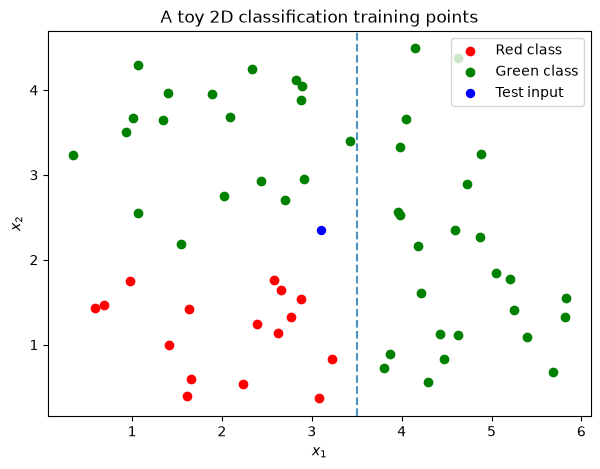

Naive 1-NN would inspect 60 training for this query
A shallow tree may need only a few feature-threshold checks


In [3]:
# A 60 point toy dataset

red = np.c_[rng.uniform(0.3, 3.3, 16), rng.uniform(0.3, 1.8, 16)]
green_top = np.c_[rng.uniform(0.3, 5.8, 30), rng.uniform(2.1, 4.9, 30)]
green_right = np.c_[rng.uniform(3.6, 5.9, 14), rng.uniform(0.4, 2.0, 14)]

X_toy = np.vstack([red, green_top, green_right])
y_toy = np.r_[
    np.zeros(len(red), dtype=int),
    np.ones(
        len(green_top) + len(green_right),
        dtype=int,
    ),
]
test_point = np.array([[3.1, 2.35]])

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_toy[y_toy == 0, 0], X_toy[y_toy == 0, 1], label="Red class", c="r")
ax.scatter(X_toy[y_toy == 1, 0], X_toy[y_toy == 1, 1], label="Green class", c="g")
ax.scatter(
    test_point[:, 0], test_point[:, 1], s=18, linewidths=2.5, label="Test input", c="b"
)
ax.axvline(3.5, linestyle="--", alpha=0.8)
ax.set(xlabel="$x_1$", ylabel="$x_2$", title="A toy 2D classification training points")
ax.legend()
plt.show()

print(f"Naive 1-NN would inspect {len(X_toy)} training for this query")
print("A shallow tree may need only a few feature-threshold checks")

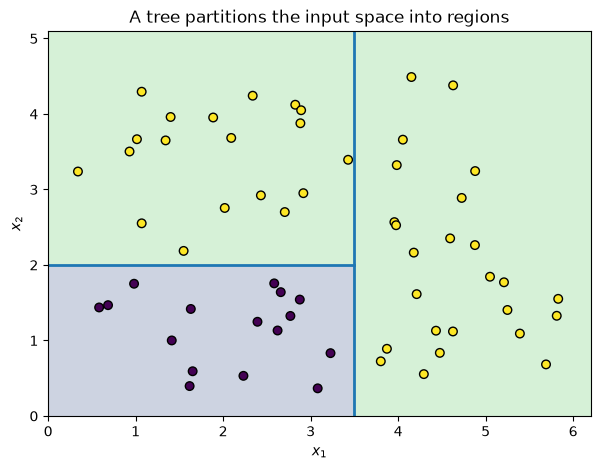

x=[2.3 1.2]-> predicted class 0
x=[2.4 3.1]-> predicted class 1
x=[4.4 3.4]-> predicted class 1


In [4]:
# decision logic for above classification


def hand_tree_predict(X):
    X = np.asarray(X)
    pred = np.zeros(len(X), dtype=int)
    pred[X[:, 0] > 3.5] = 1
    pred[(X[:, 0] <= 3.5) & (X[:, 1] > 2)] = 1
    return pred


# visualization

x1 = np.linspace(0, 6.2, 300)
x2 = np.linspace(0, 5.1, 250)
xx, yy = np.meshgrid(x1, x2)

zz = hand_tree_predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 5))
ax.contourf(xx, yy, zz, levels=[-0.5, 0.5, 1.5], alpha=0.25)
ax.scatter(X_toy[:, 0], X_toy[:, 1], c=y_toy, edgecolor="k", s=38)
ax.axvline(3.5, linewidth=2)
ax.plot([0, 3.5], [2, 2], linewidth=2)
ax.set(
    xlabel="$x_1$",
    ylabel="$x_2$",
    title="A tree partitions the input space into regions",
)
plt.show()

for p in np.array([[2.3, 1.2], [2.4, 3.1], [4.4, 3.4]]):
    print(f"x={p}-> predicted class {hand_tree_predict([p])[0]}")

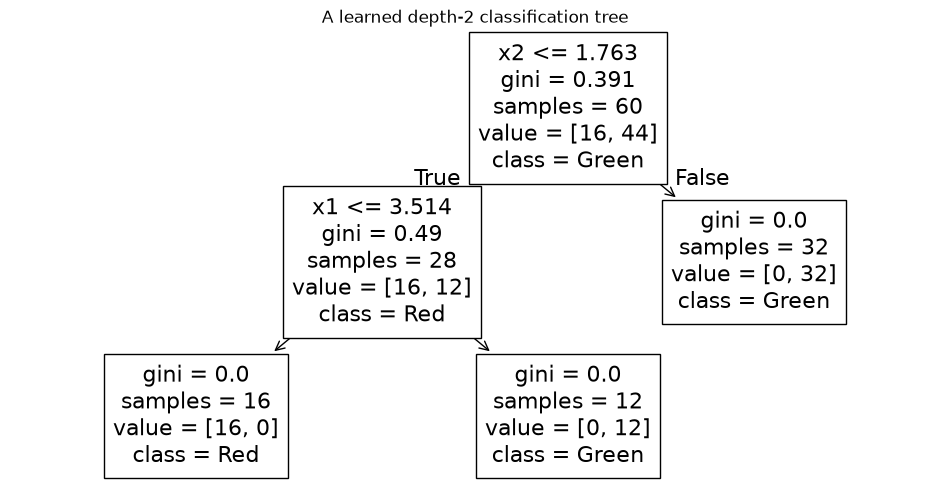

,n,green_fraction
leaf_id,,
2,16,0.0
3,12,1.0
4,32,1.0


In [5]:
clf = DecisionTreeClassifier(
    max_depth=2,
    criterion="gini",
    random_state=RANDOM_STATE,
)
clf.fit(X_toy, y_toy)

fig, ax = plt.subplots(figsize=(12, 6))
plot_tree(
    clf,
    feature_names=["x1", "x2"],
    class_names=["Red", "Green"],
    ax = ax
)
ax.set_title('A learned depth-2 classification tree')
plt.show()

leaf_id = clf.apply(X_toy)
leaf_table = pd.DataFrame({
    'leaf_id':leaf_id,
    'class': y_toy
}).groupby('leaf_id').agg(
    n=('class', 'size'),
    green_fraction=('class','mean')
)
leaf_table

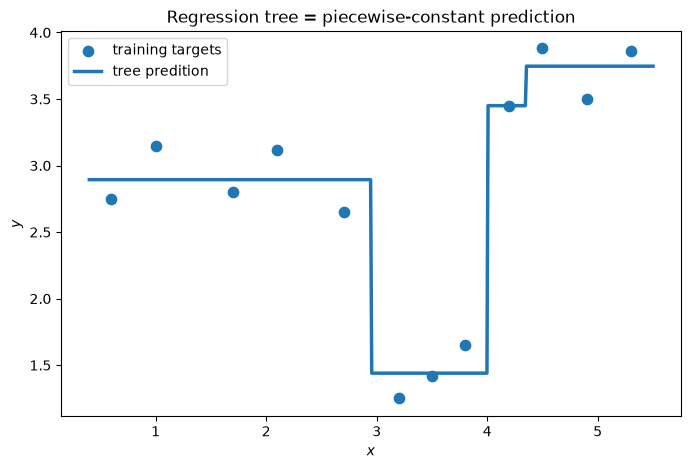

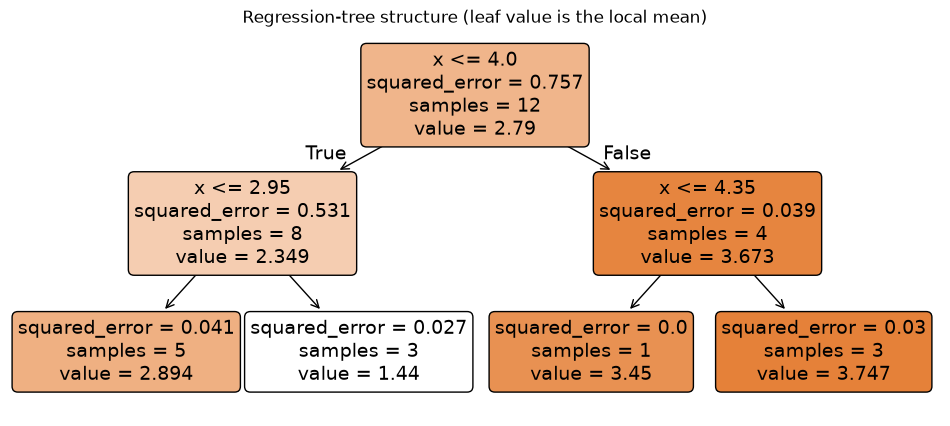

In [6]:
# A small 1D regression example with three natural regions.
X_reg = np.array([0.6, 1.0, 1.7, 2.1, 2.7, 3.2, 3.5, 3.8, 4.2, 4.5, 4.9, 5.3])[:, None]
y_reg = np.array(
    [2.75, 3.15, 2.80, 3.12, 2.65, 1.25, 1.42, 1.65, 3.45, 3.88, 3.50, 3.86]
)

reg_tree = DecisionTreeRegressor(max_depth=2, random_state=RANDOM_STATE)
reg_tree.fit(X_reg, y_reg)

grid = np.linspace(0.4, 5.5, 500)[:, None]
pred = reg_tree.predict(grid)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_reg[:, 0], y_reg, s=55, label="training targets")

ax.plot(grid[:, 0], pred, linewidth=2.5, label="tree predition")
ax.set(
    xlabel="$x$",
    ylabel="$y$",
    title="Regression tree = piecewise-constant prediction",
)
ax.legend()
plt.show()

fig,ax = plt.subplots(figsize=(12,5))
plot_tree(reg_tree, feature_names=["x"], filled=True, rounded=True, ax=ax)
ax.set_title("Regression-tree structure (leaf value is the local mean)")

plt.show()

In [7]:
def gini_impurity(labels):
    labels= np.asarray(labels)
    if len(labels) == 0:
        return 0.0
    _, counts = np.unique(labels, return_counts=True)
    p = counts/ counts.sum()
    return 1 - np.sum(p**2)

def entropy(labels):
    labels=np.asarray(labels)
    if len(labels)==0:
        return 0.0
    _, counts = np.unique(labels, return_counts=True)
    p = counts/np.sum(counts)
    return -np.sum(p* np.log2(p))

def regression_mse(targets):
    targets = np.asarray(targets, dtype=float)
    if len(targets) == 0:
        return 0.0

    return np.mean((targets - targets.mean())**2)


sample_data = {
    'pure': [0,0,0,0,0,0],
    'imbalanced': [0,0,0,0,0,1],
    'mixed': [0,0,0,1,1,1]
}

pd.DataFrame(sample_data)



,pure,imbalanced,mixed
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,1
4,0,0,1
5,0,1,1


In [8]:
pd.DataFrame([
    {'node': name, 'Gini': gini_impurity(y), 'Entropy': entropy(y)}
    for name, y in sample_data.items()
])

,node,Gini,Entropy
0,pure,0.000000,-0.000000
1,imbalanced,0.277778,0.650022
2,mixed,0.500000,1.000000


In [9]:
def binary_split_gain(labels, left_mask, impurity_fn=gini_impurity):
    labels = np.asarray(labels)
    left_mask = np.asarray(left_mask, dtype=bool)
    right_mask = ~left_mask
    n = len(labels)
    parent_impurity = impurity_fn(labels)
    left_impurity = impurity_fn(labels[left_mask])
    right_impurity = impurity_fn(labels[right_mask])
    information_gain = parent_impurity - left_mask.mean() * left_impurity - right_mask.mean() * right_impurity
    return information_gain


In [10]:
parent = np.array([0,1] * 6)
parent

array([0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1])

In [11]:
weak_left = np.array([True, True, False, False] * 3)
strong_left = np.array([True] * 6 + [False] * 6)
strong_labels = np.array([0]*5 + [1] + [0] + [1]*5)
pd.DataFrame({'parent':parent,'weak_left': weak_left, 'strong_left':strong_left, 'strong_labels':strong_labels})

,parent,weak_left,strong_left,strong_labels
0,0,True,True,0
1,1,True,True,0
2,0,False,True,0
3,1,False,True,0
4,0,True,True,0
5,1,True,True,1
6,0,False,False,0
7,1,False,False,1
8,0,True,False,1
9,1,True,False,1


In [12]:
print('Weak-split gain (Gini):', round(binary_split_gain(parent,weak_left), 4))
print("Strong-split gain (Gini):", round(binary_split_gain(strong_labels, strong_left), 4))

Weak-split gain (Gini): 0.0
Strong-split gain (Gini): 0.2222


In [13]:
xj = np.array([1.2, 1.8, 2.7, 3.1, 3.6, 4.2, 4.8, 5.3])
yj = np.array([0, 1, 0, 1, 2, 2, 1, 2])

thresholds = (xj[:-1] + xj[1:])/2
thresholds

array([1.5 , 2.25, 2.9 , 3.35, 3.9 , 4.5 , 5.05])

In [14]:
rows = []
for t in thresholds:
    left = xj <=t
    rows.append(
        {
            'threshold': t,
            'left_n': int(left.sum()),
            'right_n': int((~left).sum()),
            'left_counts': tuple(np.bincount(yj[left], minlength=3)),
            'right_counts': tuple(np.bincount(yj[~left], minlength=3)),
            'Gini gain': round(binary_split_gain(yj, left, gini_impurity),4)
        }
    )
threshold_table = pd.DataFrame(rows)

threshold_table

,threshold,left_n,right_n,left_counts,right_counts,Gini gain
0,1.50,1,7,"(1, 0, 0)","(1, 3, 3)",0.1205
1,2.25,2,6,"(1, 1, 0)","(1, 2, 3)",0.0729
2,2.90,3,5,"(2, 1, 0)","(0, 2, 3)",0.1896
3,3.35,4,4,"(2, 2, 0)","(0, 1, 3)",0.2188
4,3.90,5,3,"(2, 2, 1)","(0, 1, 2)",0.0896
5,4.50,6,2,"(2, 2, 2)","(0, 1, 1)",0.0312
6,5.05,7,1,"(2, 3, 2)","(0, 0, 1)",0.0848


In [15]:
best_idx = threshold_table['Gini gain'].idxmax()
best_t = threshold_table.loc[best_idx, 'threshold']
print(f'Best threshold: {best_t}, Max Information Gain: { threshold_table.loc[best_idx, 'Gini gain']}')

Best threshold: 3.35, Max Information Gain: 0.2188


In [16]:
#Categorical data

weather = np.array(['Sunny']*4 + ['Cloudy']*4 + ['Rainy']*4)
y_weather = np.array([
    0,0,0,1, 
    1,1,1,0,
    2,2,2,1
])
pd.DataFrame({'weather': weather, 'label': y_weather})

,weather,label
0,Sunny,0
1,Sunny,0
2,Sunny,0
3,Sunny,1
4,Cloudy,1
5,Cloudy,1
6,Cloudy,1
7,Cloudy,0
8,Rainy,2
9,Rainy,2


In [17]:
parent_impurity = gini_impurity(y_weather)
print('Parent Gini: ', round(parent_impurity,4))


weighted = 0
for category in np.unique(weather):
    m = weather == category
    weighted += m.mean() * gini_impurity(y_weather[m])
    print(f'{category:>7} counts={np.bincount(y_weather[m], minlength=3)}, Gini={gini_impurity(y_weather[m])}')

print('Mulitway Gain: ', round(parent_impurity - weighted, 4))

Parent Gini:  0.6528
 Cloudy counts=[1 3 0], Gini=0.375
  Rainy counts=[0 1 3], Gini=0.375
  Sunny counts=[3 1 0], Gini=0.375
Mulitway Gain:  0.2778


In [18]:
# enumerate unique binary partitions 
category = np.array(['Sunny', 'Cloudy', 'Rainy'])
binary_rows = []
for right_choice in [['Cloudy'], ['Rainy'], ['Cloudy', 'Rainy']]:
    right_set = set(right_choice)
    left_mask = np.array([w not in right_set for w in weather])
    binary_rows.append({
        'left_categories': tuple(sorted(set(weather[left_mask]))),
        'right categories': tuple(sorted(right_set)),
        'Gini gain': binary_split_gain(y_weather, left_mask, gini_impurity)
    })
display(pd.DataFrame(binary_rows).sort_values('Gini gain', ascending=False))

,left_categories,right categories,Gini gain
1,"(Cloudy, Sunny)","(Rainy,)",0.194444
2,"(Sunny,)","(Cloudy, Rainy)",0.131944
0,"(Rainy, Sunny)","(Cloudy,)",0.090278


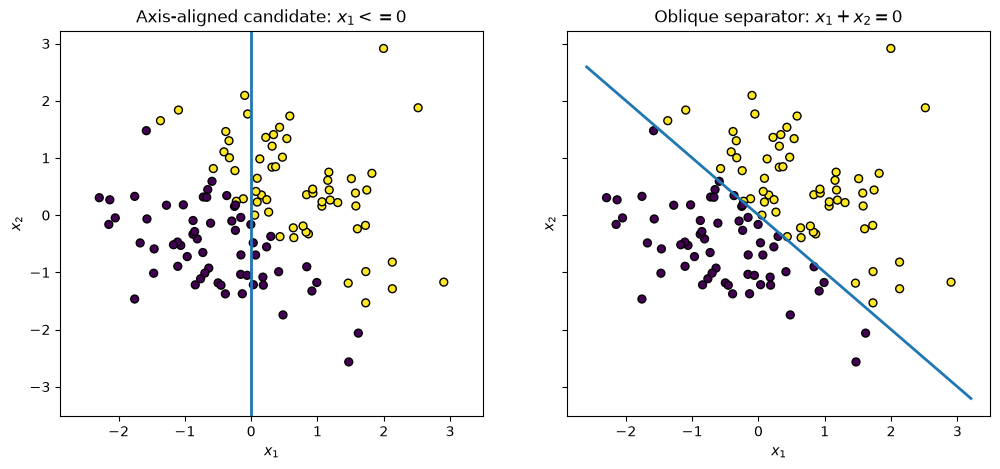

Gini gain of axis-aligned split: 0.1607
Gini gain of oblique split:      0.5000


In [19]:
# Visual comparison of an axis-aligned and an oblique split.
X_ob = rng.normal(size=(120, 2))
y_ob = (X_ob[:, 0] + X_ob[:, 1] > 0).astype(int) # y1= int(x1+x2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
for ax in axes:
    ax.scatter(X_ob[:, 0], X_ob[:, 1], c=y_ob, edgecolor="k", s=32)
    ax.set(xlabel="$x_1$", ylabel="$x_2$")

axes[0].axvline(0, linewidth=2)
axes[0].set_title("Axis-aligned candidate: $x_1 <= 0$")

xx_line = np.linspace(X_ob[:, 0].min() - 0.3, X_ob[:, 0].max() + 0.3, 200)
axes[1].plot(xx_line, -xx_line, linewidth=2)
axes[1].set_title(r"Oblique separator: $x_1+x_2=0$")
plt.show()

axis_gain = binary_split_gain(y_ob, X_ob[:, 0] <= 0)
oblique_gain = binary_split_gain(y_ob, X_ob[:, 0] + X_ob[:, 1] <= 0)
print(f"Gini gain of axis-aligned split: {axis_gain:.4f}")
print(f"Gini gain of oblique split:      {oblique_gain:.4f}")


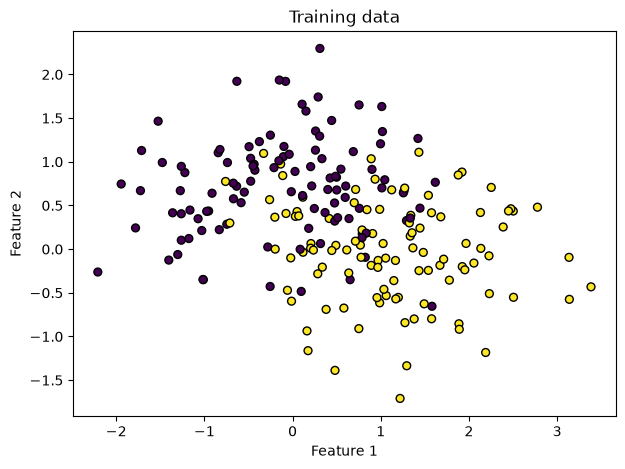

In [34]:
# Nonlinear 2D data for studying depth and ensembles

X, y = make_moons(n_samples = 300, noise=0.5, random_state=RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)

def plot_decision_boundary(model, X_data, y_data, title, ax=None, grid_step = 0.025):
    if ax is None:
        _, ax= plt.subplots(figsize=(7,5))
    x_min, x_max = X[:,0].min() - 0.6, X[:, 0].max() + 0.6
    y_min, y_max = X[:,1].min() - 0.6, X[:, 1].max() + 0.6
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, grid_step),
        np.arange(y_min, y_max, grid_step),
    )
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.22)
    ax.scatter(X_data[:, 0], X_data[:, 1], c=y_data, edgecolors='k', s=30)
    ax.set(xlabel='Feature 1', ylabel='Feature 2', title = title)
    return ax

fig, ax = plt.subplots(figsize=(7,5))
ax.scatter(X_train[:,0], X_train[:,1], c=y_train, edgecolors='k', s=32)
ax.set(xlabel='Feature 1', ylabel='Feature 2', title = 'Training data')
plt.show()

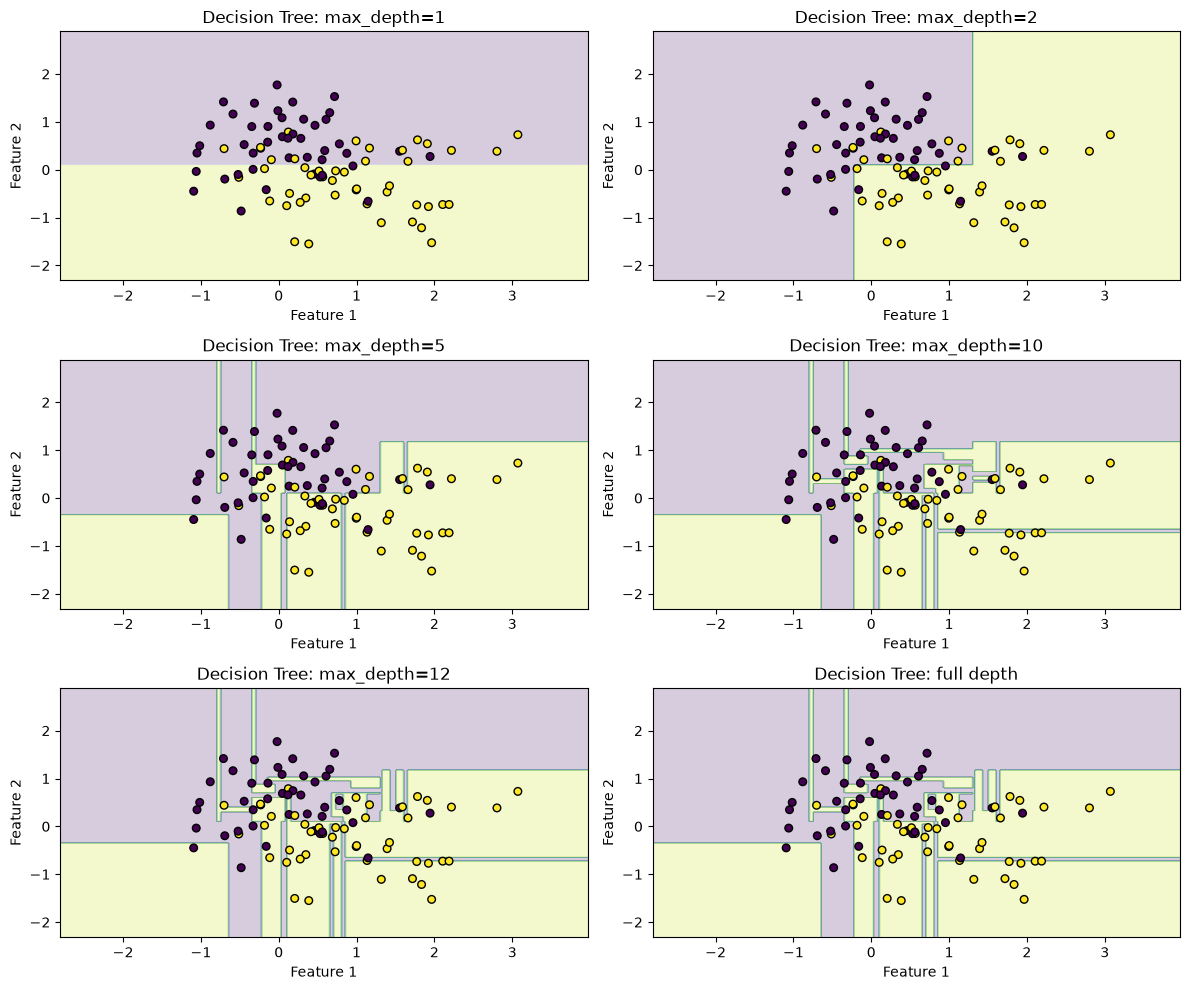

,max_depth,actual_depth,train_accuracy,test_accuracy
0,1,1,0.747619,0.700000
1,2,2,0.838095,0.811111
2,5,5,0.900000,0.733333
3,10,10,0.995238,0.700000
4,12,12,1.000000,0.711111
5,None (full),12,1.000000,0.711111


In [35]:
depth_settings = [1, 2, 5, 10 , 12, None]
trees = {}

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
for depth, ax in zip(depth_settings, axes.ravel()):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE)
    tree.fit(X_train, y_train)
    trees[depth] = tree
    label = "full depth" if depth is None else f"max_depth={depth}"
    plot_decision_boundary(tree, X_test, y_test, f"Decision Tree: {label}", ax=ax)
plt.tight_layout()
plt.show()

accuracy_rows = []
for depth, tree in trees.items():
    accuracy_rows.append(
        {
            "max_depth": "None (full)" if depth is None else str(depth),
            "actual_depth": tree.tree_.max_depth,
            "train_accuracy": tree.score(X_train, y_train),
            "test_accuracy": tree.score(X_test, y_test),
        }
    )
accuracy_df = pd.DataFrame(accuracy_rows)
display(accuracy_df)


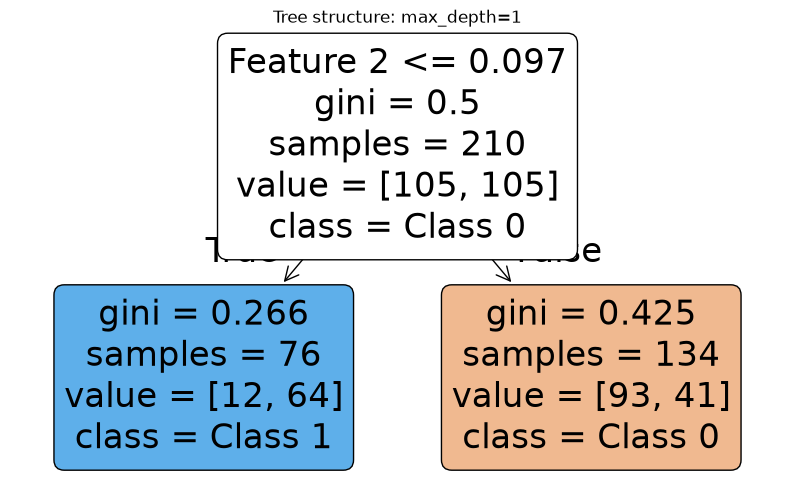

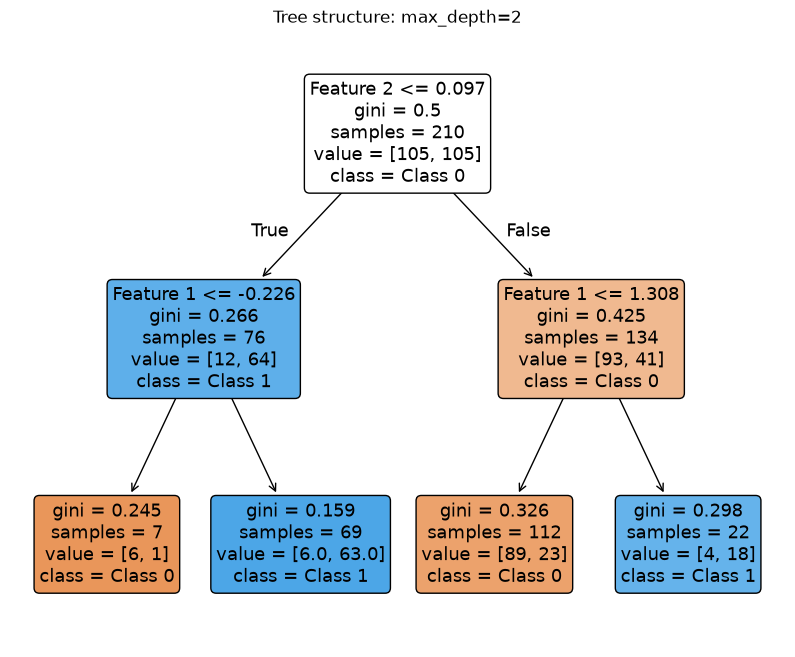

In [36]:
# Plot tree structure for the simplest cases, where the rules are easy to read.
for depth in [1, 2]:
    fig, ax = plt.subplots(figsize=(10, 6 if depth == 1 else 8))
    plot_tree(
        trees[depth],
        filled=True,
        rounded=True,
        ax=ax,
        feature_names=["Feature 1", "Feature 2"],
        class_names=["Class 0", "Class 1"],
    )
    ax.set_title(f"Tree structure: max_depth={depth}")
    plt.show()



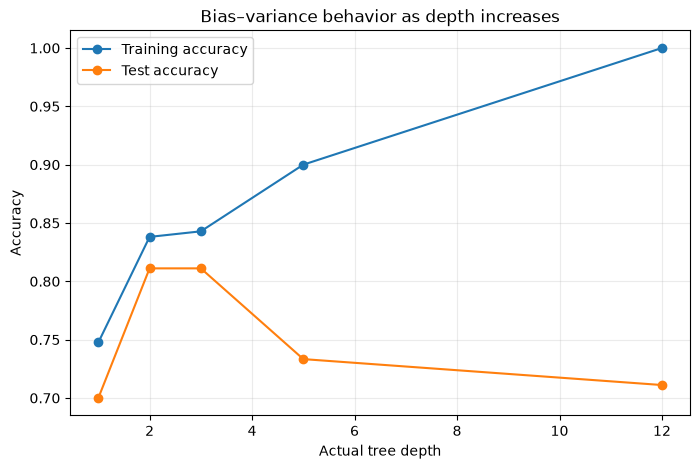

In [37]:
# training and test accuracy versus depth, including one extra intermediate depth

depths = [1, 2, 3, 5, None]

models_by_depth = {}
rows = []

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE).fit(
        X_train, y_train
    )
    models_by_depth[d] = model
    rows.append(
        (
            d,
            model.tree_.max_depth,
            model.score(X_train, y_train),
            model.score(X_test, y_test),
        )
    )
actual_depths = [r[1] for r in rows]
train_accuracy = [r[2] for r in rows]
test_accuracy = [r[3] for r in rows]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(actual_depths, train_accuracy, marker="o", label="Training accuracy")
ax.plot(actual_depths, test_accuracy, marker="o", label="Test accuracy")
ax.set(
    xlabel="Actual tree depth",
    ylabel="Accuracy",
    title="Bias–variance behavior as depth increases",
)
ax.legend()
ax.grid(alpha=0.25)
plt.show()

,count,mean_threshold,std_threshold
root_feature,,,
0,29,0.670728,0.388728
1,51,0.294608,0.222918


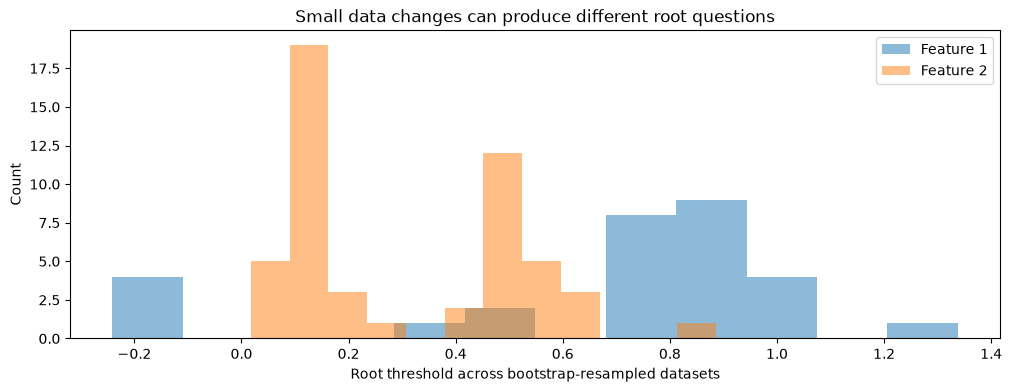

In [38]:
# Large depth trees are unstable and susceptible to noise

root_rules = []
for b in range(80):
    idx = rng.choice(len(X_train), size=len(X_train), replace=True)
    m = DecisionTreeClassifier(random_state=b).fit(X_train[idx], y_train[idx])
    feature = m.tree_.feature[0]
    threshold = m.tree_.threshold[0]
    root_rules.append((feature, threshold))

root_df = pd.DataFrame(root_rules, columns=["root_feature", "root_threshold"])
display(
    root_df.groupby("root_feature").agg(
        count=("root_feature", "size"),
        mean_threshold=("root_threshold", "mean"),
        std_threshold=("root_threshold", "std"),
    )
)

fig, ax = plt.subplots(figsize=(12, 4))
for f in sorted(root_df.root_feature.unique()):
    vals = root_df.loc[root_df.root_feature == f, "root_threshold"]
    ax.hist(vals, bins=12, alpha=0.5, label=f"Feature {f + 1}")
ax.set(
    xlabel="Root threshold across bootstrap-resampled datasets",
    ylabel="Count",
    title="Small data changes can produce different root questions",
)
ax.legend()
plt.show()


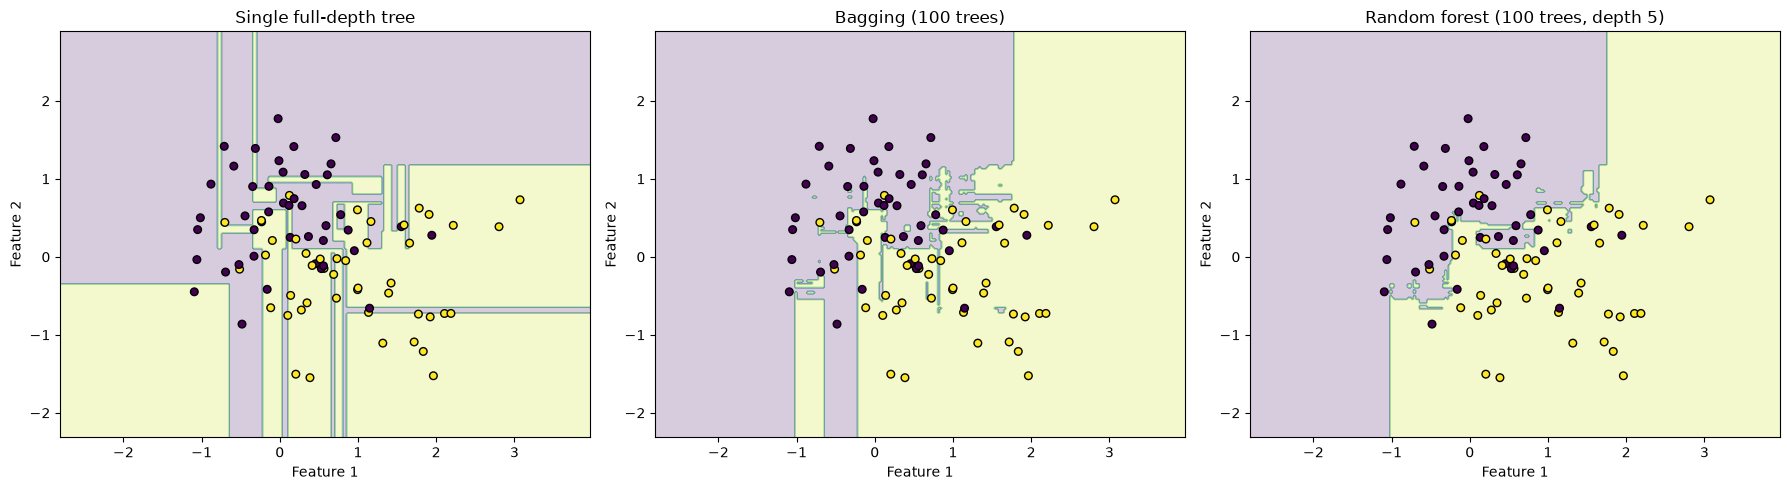

,train_accuracy,test_accuracy
model,,
Single full-depth tree,1.0,0.711111
Bagging (100 trees),1.0,0.800000
"Random forest (100 trees, depth 5)",0.9,0.822222


In [39]:
# Compare one full-depth tree, bagging of full-depth trees, and a random forest.
single_full = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(X_train, y_train)

bag = BaggingClassifier(
    estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
    n_estimators=100,
    bootstrap=True,
    random_state=RANDOM_STATE,
    n_jobs=1,
).fit(X_train, y_train)

rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    max_features="sqrt",
    random_state=RANDOM_STATE,
    n_jobs=1,
).fit(X_train, y_train)

models = {
    "Single full-depth tree": single_full,
    "Bagging (100 trees)": bag,
    "Random forest (100 trees, depth 5)": rf,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for (name, model), ax in zip(models.items(), axes):
    plot_decision_boundary(model, X_test, y_test, name, ax=ax)
plt.tight_layout()
plt.show()

pd.DataFrame(
    [
        {
            "model": name,
            "train_accuracy": model.score(X_train, y_train),
            "test_accuracy": model.score(X_test, y_test),
        }
        for name, model in models.items()
    ]
).set_index("model")


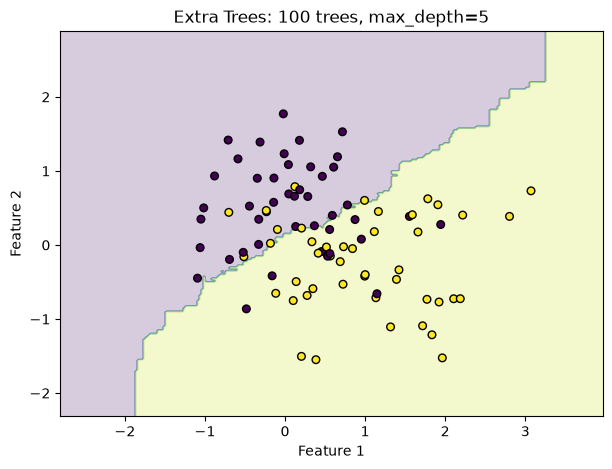

Train accuracy: 0.819
Test accuracy:  0.789


In [40]:
extra = ExtraTreesClassifier(
    n_estimators=100, max_depth=5, random_state=RANDOM_STATE, n_jobs=1
)
extra.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(7, 5))
plot_decision_boundary(
    extra, X_test, y_test, "Extra Trees: 100 trees, max_depth=5", ax=ax
)
plt.show()
print(f"Train accuracy: {extra.score(X_train, y_train):.3f}")
print(f"Test accuracy:  {extra.score(X_test, y_test):.3f}")


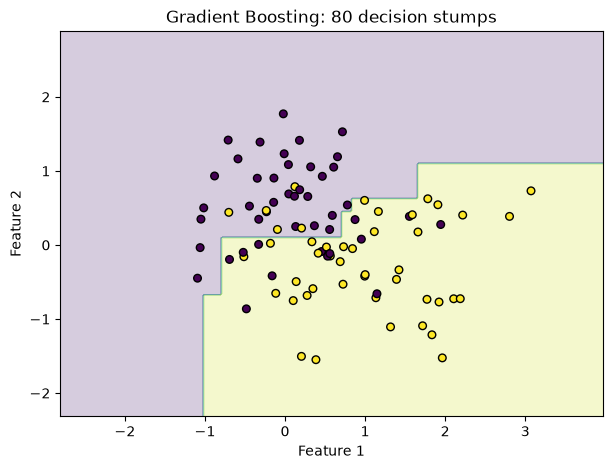

In [41]:
# Boosting

gb = GradientBoostingClassifier(
    n_estimators=80,
    learning_rate=0.08,
    max_depth=1, #decision_stumps
    random_state=RANDOM_STATE
).fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(7,5))
plot_decision_boundary(gb, X_test, y_test, 'Gradient Boosting: 80 decision stumps', ax=ax)
plt.show()



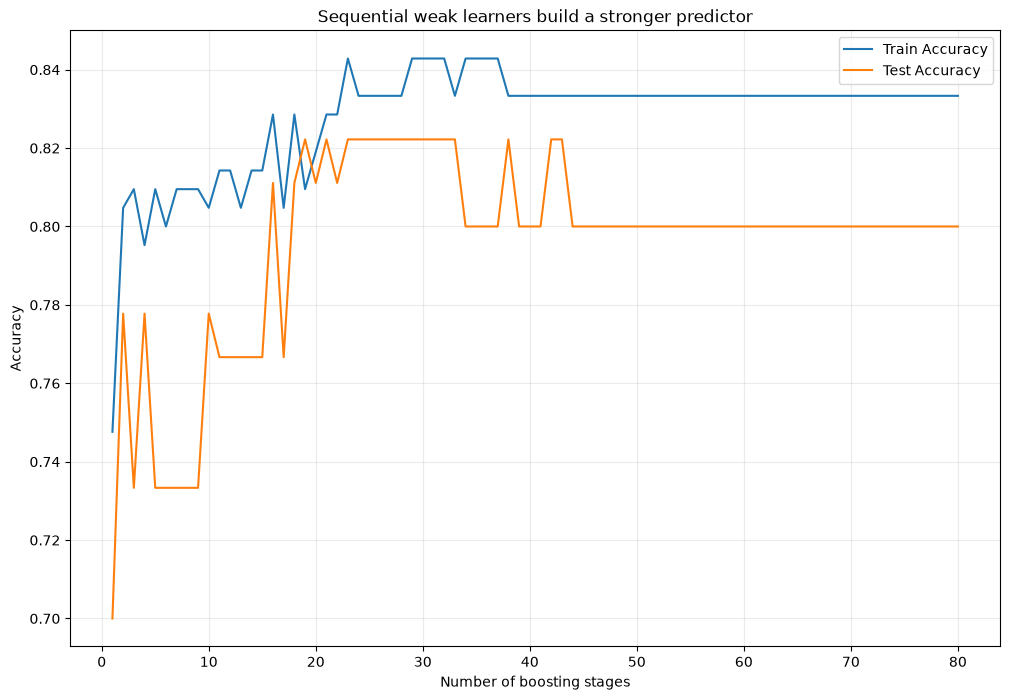

Final Train accuracy: 0.833
Final Test accuracy: 0.800


In [42]:
train_curve = [accuracy_score(y_train, p) for p in gb.staged_predict(X_train)]
test_curve = [accuracy_score(y_test, p) for p in gb.staged_predict(X_test)]

fig, ax = plt.subplots(figsize=(12,8))
ax.plot(np.arange(1, len(train_curve)+1), train_curve, label='Train Accuracy')
ax.plot(np.arange(1, len(test_curve) + 1), test_curve, label="Test Accuracy")
ax.set(xlabel='Number of boosting stages', ylabel='Accuracy', title='Sequential weak learners build a stronger predictor')
ax.legend()
ax.grid(alpha=0.25)
plt.show()

print(f'Final Train accuracy: {gb.score(X_train, y_train):.3f}')
print(f"Final Test accuracy: {gb.score(X_test, y_test):.3f}")

,train_accuracy,test_accuracy
model,,
DT depth 1,0.747619,0.700000
DT depth 5,0.900000,0.733333
DT full depth,1.000000,0.711111
Bagging/Bootstrapping,1.000000,0.800000
Random Forest,0.900000,0.822222
Gradient Boosting,0.833333,0.800000


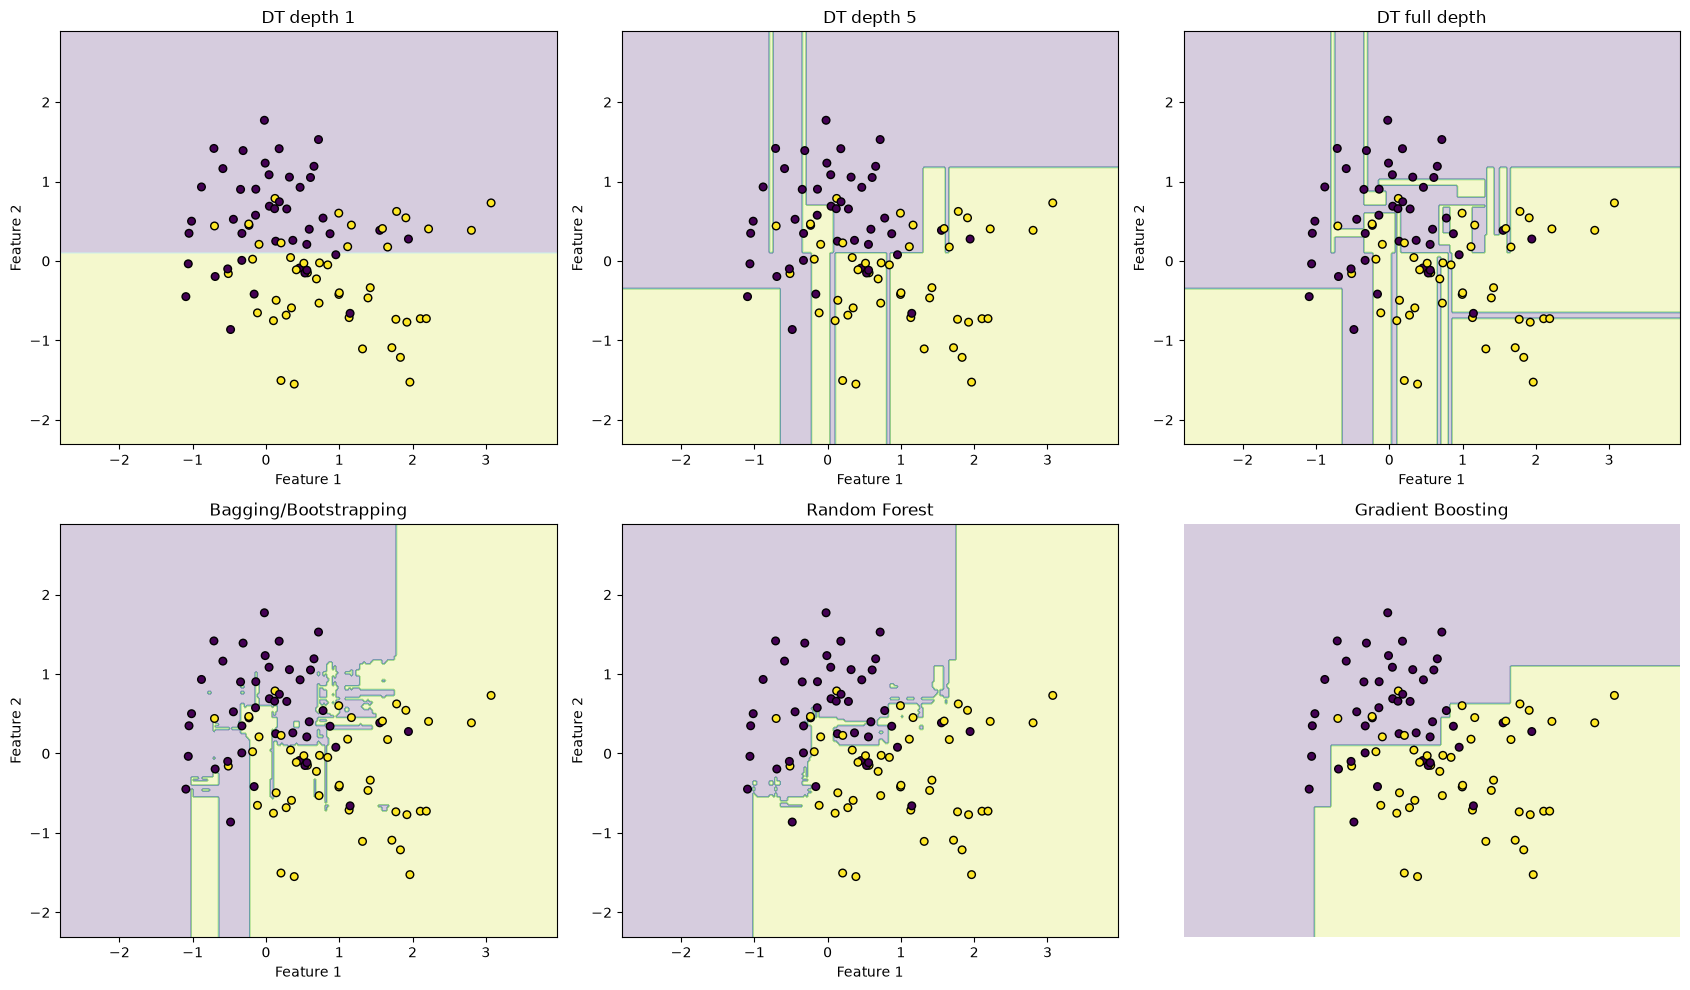

In [45]:
comparison_models = {
    "DT depth 1": DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE),
    "DT depth 5": DecisionTreeClassifier(max_depth=5, random_state=RANDOM_STATE),
    "DT full depth": DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Bagging/Bootstrapping": BaggingClassifier(
        n_estimators=100,random_state=RANDOM_STATE,n_jobs=1
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100, max_depth=5, random_state=RANDOM_STATE, n_jobs=1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=80, learning_rate=0.08, max_depth=1, random_state=RANDOM_STATE
    ),
}

comparison_rows = []
for name, model in comparison_models.items():
    model.fit(X_train, y_train)
    comparison_rows.append(
        {
            "model": name,
            "train_accuracy": model.score(X_train, y_train),
            "test_accuracy": model.score(X_test, y_test),
        }
    )

comparison_df = pd.DataFrame(comparison_rows).set_index("model")
display(comparison_df)

fig, axes = plt.subplots(2, 3, figsize=(17, 10))
for ax, (name, model) in zip(axes.ravel(), comparison_models.items()):
    plot_decision_boundary(model, X_test, y_test, name, ax=ax)
axes.ravel()[-1].axis("off")
plt.tight_layout()
plt.show()
